<h1 style="text-align: center; font-family: 'menlo'; color: #FFF243; font-size:50px;">
  <span style="background-color: #FA9500; padding: 5px 10px; border-radius: 5px; display: inline-block;">
         About bias and overscan
  </span>
</h1>

# Sample bias images

The images below are a single bias frame and an average 100 bias frames from an [Andor Apogee Aspen CG16M](https://andor.oxinst.com/downloads/uploads/Apogee_Aspen_Hardware_Guide.pdf), a low-end 4k × 4k CCD with a [Kodak KAF-16803 sensor chip](https://www.onsemi.com/pdf/datasheet/kaf-16803-d.pdf). That model camera has a typical bias level around 1000 and read noise around $10e^-$, though the precise value varies from camera to camera and with temperature.

In [9]:
%load_ext autoreload 
    # carrega a extensão autoreload do IPython/Jupyter
%autoreload 2 
    #faz com que todos os módulos sejam recarregados automaticamente antes de executar qualquer célula 
    # útil durante o desenvolvimento — se editar um arquivo .py externo (como convenience_functions.py), 
    # as mudanças são refletidas sem precisar reiniciar o kernel

In [10]:
from astropy.nddata import CCDData # encapsula os dados da imagem, unidades físicas (adu, electron), metadados do header FITS, máscaras de pixels ruins e incertezas
from astropy.visualization import hist # hist do astropy, é uma versão melhorada do histograma do matplotlib pra dados astro
import numpy as np

%matplotlib inline 
    # pros gráficos ficarem aqui e nao abrir um popup
import matplotlib.pyplot as plt
plt.style.use('guide.mplstyle')

from convenience_functions import show_image

In [11]:
one_bias = CCDData.read('single_bias_thermoelectric.fit.bz2', unit='adu') 
one_hundred_bias = CCDData.read('combined_bias_100_images.fit.bz2', unit='adu')

# depois do read eh o nome do arquivo né e a unidade 

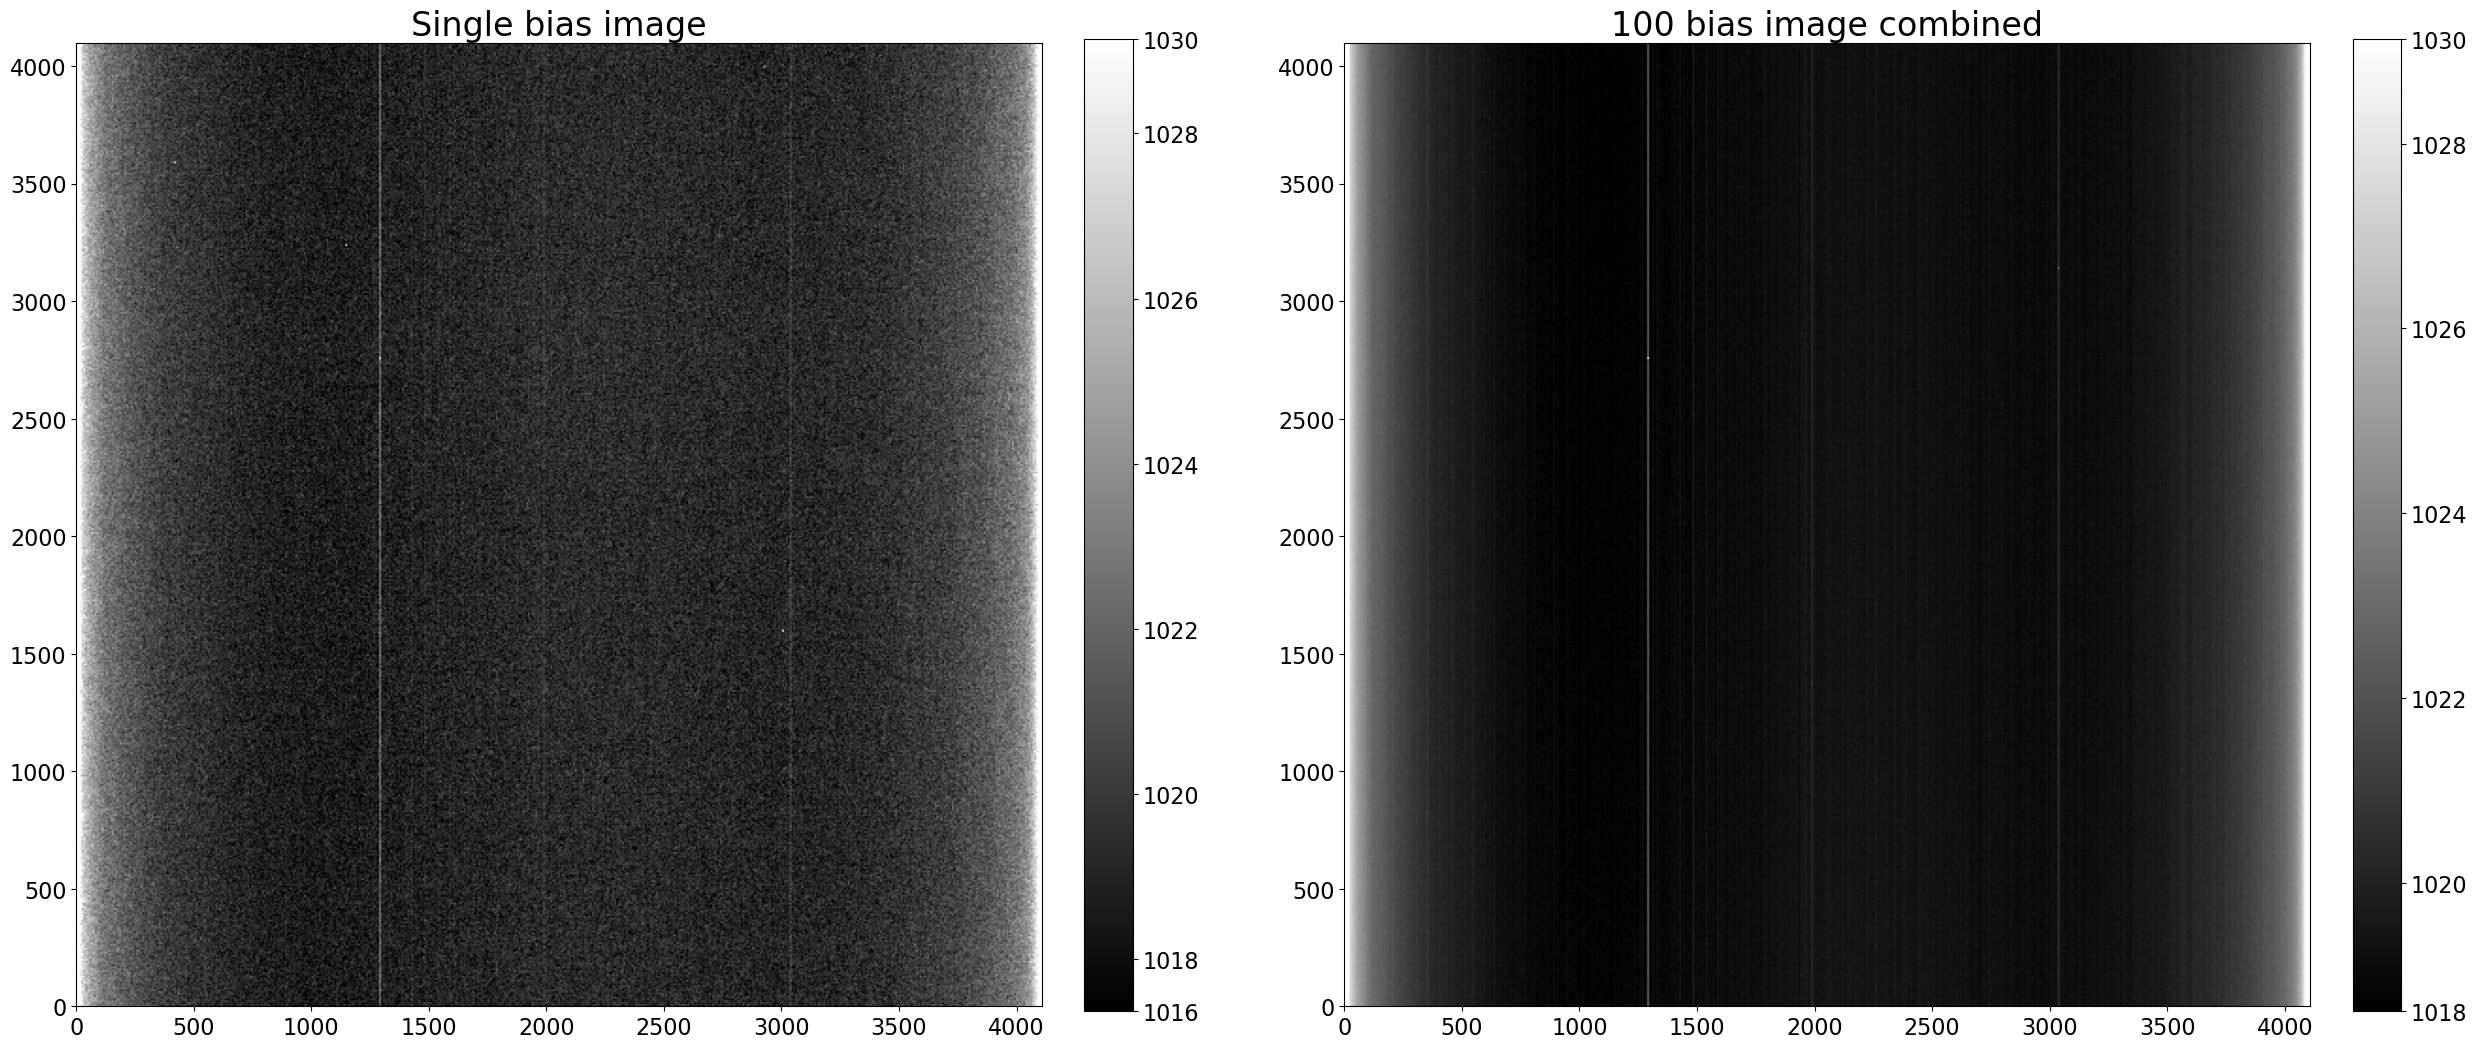

In [12]:
fig, (ax_1_bias, ax_avg_bias) = plt.subplots(1, 2, figsize=(30, 15)) 
    # subplot 1, 2 = 1 linha e 2 colunas ,, 30 largura e 15 altura
    # ax=ax_1_bias = diz para a função show_image desenhar nesse subplot específico, mesma coisa com ax_avg_bias

show_image(one_bias.data, cmap='gray', ax=ax_1_bias, fig=fig, input_ratio=8)
ax_1_bias.set_title('Single bias image')

show_image(one_hundred_bias.data, cmap='gray', ax=ax_avg_bias, fig=fig, input_ratio=8)
ax_avg_bias.set_title('100 bias image combined');

# input_ratio = parâmetro custom do guia — ajusta o contraste/escala da imagem

# Note a few things 

- The bias level in this specific camera is about 1023 (the mid-range of the colorbar).

- The image is brighter on the left and right edges. This “amplifier glow” is <u>frequently present and caused by the CCD electronics</u> (photosensors with an applied voltage are LEDs).

- There are several vertical lines; these are columns for which the bias level is consistently <u>higher</u>.

- There is noticeable “static” in the images; that is <u>read noise</u>.

- None of the variations are particularly large.

- Combining several bias images vastly <u>reduces the read noise</u>. This example is a <u>little unrealistic</u> in that 100 bias images were combined, but it still illustrates the idea that combining images reduces noise.

*dá pra notar que os pixels variam de 1016 a 1030, como diz na colorbar, essa faixa é pequena comparada com 0-4000 (visto no eixo X), e a imagem da direita é relativamente uniforme (visualmente).*

In [13]:
# deepseek ajudo a descobrir quais valores seriam mais legais para colocar no plt.xlim

# Ver os valores mínimo e máximo de toda a imagem
print(f"Mínimo: {one_bias.data.min()}")
print(f"Máximo: {one_bias.data.max()}")

# Ver estatísticas da região central
regiao_central = one_bias.data[:, 15:-30]
print(f"Média: {regiao_central.mean():.2f}")
print(f"Desvio padrão: {regiao_central.std():.2f}")
print(f"Percentil 1%: {np.percentile(regiao_central, 1)}")
print(f"Percentil 99%: {np.percentile(regiao_central, 99)}")

Mínimo: 978
Máximo: 1844
Média: 1019.81
Desvio padrão: 6.52
Percentil 1%: 1005.0
Percentil 99%: 1036.0


In [14]:
# tamanho da imagem !! p saber onde como pk cortar 
one_bias = CCDData.read('single_bias_thermoelectric.fit.bz2', unit='adu')

# o nmr de linhas e colunas:
linhas, colunas = one_bias.data.shape
print(f"A imagem tem {linhas} linhas e {colunas} colunas")

A imagem tem 4096 linhas e 4109 colunas


# Impact of combining images on noise

As discussed at length in the [notebook on combination](https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/01-06-Image-combination.html), the reason for taking and combining several calibration images is to reduce the noise if the images are used for calibration. The difference between a single image and a combination of images is apparent in the images above. Another way to see the impact of combining images is in the histogram of pixel values. Notice that the distribution of values is much narrower for the combined image than for a single bias. Pixels near the edges, where the amplifier glow is large, are binned separately from the rest of the pixels to emphasize the uniformity of the chip away from the glow.

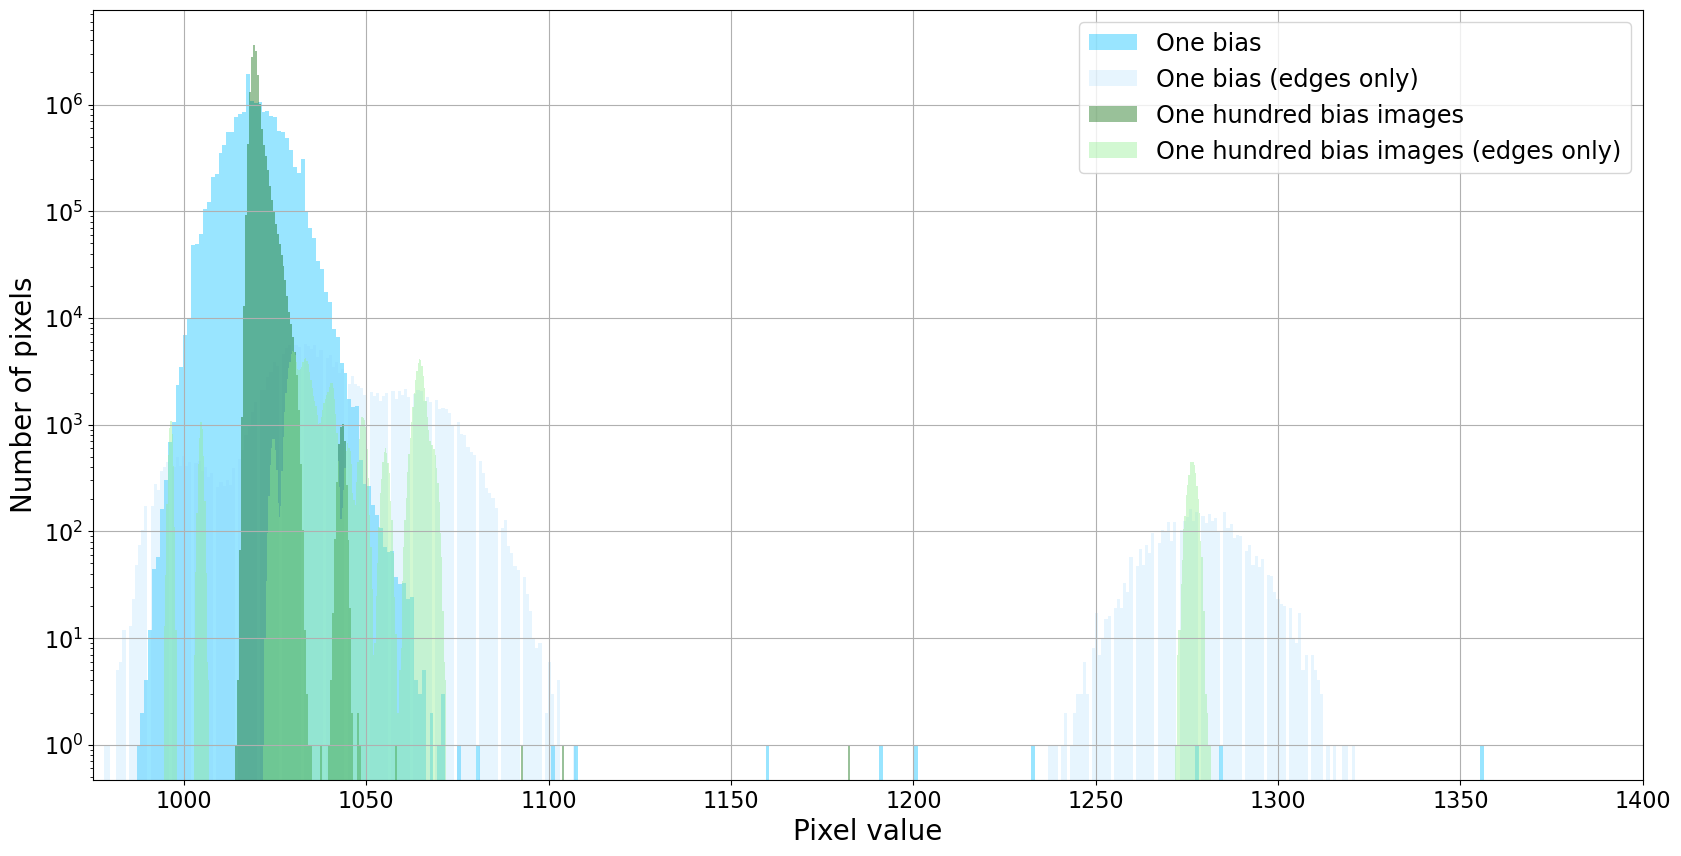

In [15]:
plt.figure(figsize=(20, 10))
hist(one_bias.data[:, 15:-30].flatten(), bins=800, alpha=0.4, label='One bias', color='deepskyblue')
hist(np.concatenate((one_bias.data[:, :15].flatten(), one_bias.data[:, -30:].flatten())), bins=400, alpha=0.2, 
     label='One bias (edges only)', color='lightskyblue')

hist(one_hundred_bias.data[:, 15:-30].flatten(), bins=800, alpha=0.4, label='One hundred bias images', color='darkgreen')
hist(np.concatenate((one_hundred_bias.data[:, :15].flatten(), one_hundred_bias.data[:, -30:].flatten())), bins=800, alpha=0.4, 
     label='One hundred bias images (edges only)', color='lightgreen')



    # [:, 15:-30] = slice da imagem, pegando todas as linhas (:),, colunas do índice 15 até 30 antes do final (-30)
        # colunas exclui antes de 15 e vai ate -30 excluindo -29,-28....
    # isso exclui as bordas esquerda e direita da imagem
    # .flatten() = transforma a matriz 2D em um array 1D, necessário para fazer o histograma
    # bins=800 = divide os dados em 800 barras no histograma
    # alpha=0.4 = transparência de 40%, para que histogramas sobrepostos sejam visíveis
    # np.concatenate... = junta dois arrays: as 15 primeiras colunas (:15) e as 30 últimas colunas (-30:) da imagem única de bias
# isso isola apenas as bordas da imagem, onde existe o "amplifier glow" — artefato eletrônico comum em CCDs

plt.grid()
plt.xlim(975, 1400)
plt.legend() # as legendas tao no hist
plt.xlabel('Pixel value')
plt.ylabel('Number of pixels')
plt.semilogy();
    # transforma o eixo y em escala logarítmica. isso é mt importante pk a distribuição de pixels tem uma cauda longa 
    # (poucos pixels com valores muito altos nas bordas) E em escala linear, a cauda seria invisível

# Bias calibration overview

The progression here is to “calibrate” the bias images by subtracting overscan, if desired, trim the overscan from the bias images if it is present, and combine all of the bias images to make a “combined” bias (another common term for these images is “master” bias and occasionally “super” bias).

<h1 style="text-align: left; font-family: 'menlo'; color: #FA9500; font-size:40px;">
  <span style="background-color: #FFF243; padding: 5px 10px; border-radius: 5px; display: inline-block;">
         Notes
  </span>
</h1>

- Matplotlib [axvline](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axvline.html) & [pyplot](https://matplotlib.org/stable/tutorials/pyplot.html).
 
---
<h1 style="text-align: left; font-family: 'menlo'; color: #FA9500; font-size:40px;">
  <span style="background-color: #FFF243; padding: 5px 10px; border-radius: 5px; display: inline-block;">
         Links
  </span>
</h1>

https://github.com/sh4rkNy/astropy-coisas/tree/main<br>https://github.com/astropy/ccd-reduction-and-photometry-guide<br>https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/02-01-overscan-trimming-and-bias-subtraction-background.html